In [4]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
import sqlite3

conn = sqlite3.connect("titanic.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS passengers (
    PassengerId INTEGER PRIMARY KEY,
    Survived INTEGER,
    Pclass INTEGER,
    Name TEXT,
    Sex TEXT,
    Age REAL,
    SibSp INTEGER,
    Parch INTEGER,
    Ticket TEXT,
    Fare REAL,
    Cabin TEXT,
    Embarked TEXT
);
""")
conn.commit()

In [18]:
df.to_sql("passengers", conn, if_exists="replace", index=False)

891

In [19]:
# Женщины старше 30
query1 = "SELECT Name, Age, Sex FROM passengers WHERE Sex = 'female' AND Age > 30;"
pd.read_sql_query(query1, conn).head()

,Name,Age,Sex
0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,female
1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,female
2,"Bonnell, Miss. Elizabeth",58.0,female
3,"Hewlett, Mrs. (Mary D Kingcome)",55.0,female
4,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",31.0,female


In [20]:
# Пассажиры из 1 класса, которые выжили
query2 = "SELECT Name, Pclass, Survived FROM passengers WHERE Pclass = 1 AND Survived = 1;"
pd.read_sql_query(query2, conn).head()

,Name,Pclass,Survived
0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,1
1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,1
2,"Bonnell, Miss. Elizabeth",1,1
3,"Sloper, Mr. William Thompson",1,1
4,"Spencer, Mrs. William Augustus (Marie Eugenie)",1,1


In [21]:
# Средний возраст
query3 = "SELECT AVG(Age) as Average_Age FROM passengers;"
pd.read_sql_query(query3, conn)

,Average_Age
0,29.699118


In [22]:
# Количество выживших
query4 = "SELECT COUNT(*) as Survivors FROM passengers WHERE Survived = 1;"
pd.read_sql_query(query4, conn)

,Survivors
0,342


In [1]:
# Сумма стоимости билетов по классам
query5 = "SELECT Pclass, SUM(Fare) as Total_Fare FROM passengers GROUP BY Pclass;"
pd.read_sql_query(query5, conn)

NameError: name 'pd' is not defined

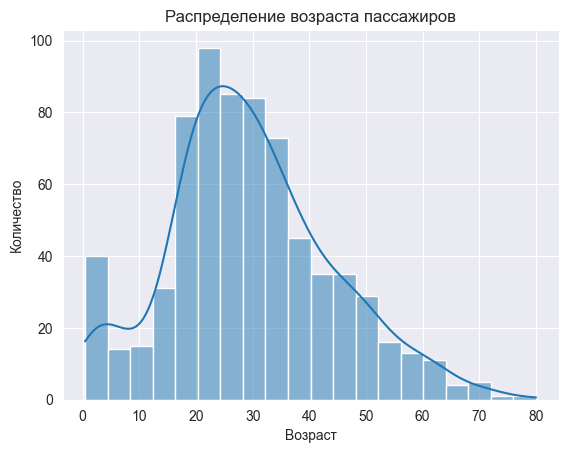

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Распределение возраста
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

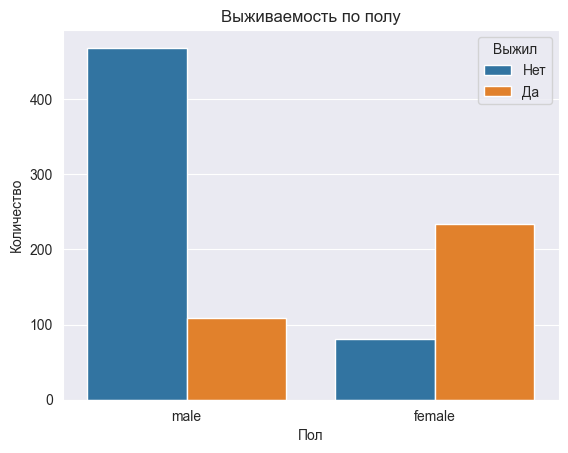

In [16]:
# Выживаемость по полу
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Выживаемость по полу')
plt.xlabel('Пол')
plt.ylabel('Количество')
plt.legend(title='Выжил', labels=['Нет', 'Да'])
plt.show()

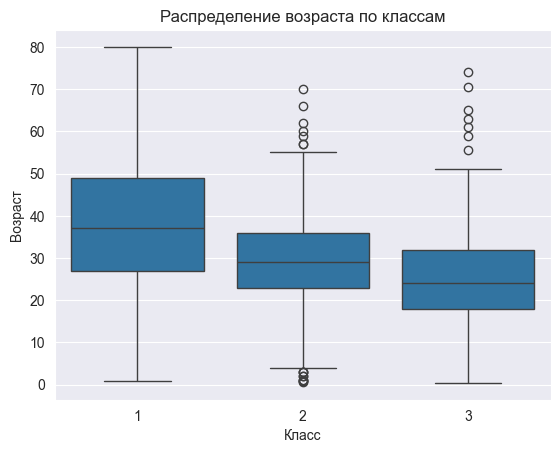

In [17]:
# Boxplot возраста по классам
sns.boxplot(data=df, x='Pclass', y='Age')
plt.title('Распределение возраста по классам')
plt.xlabel('Класс')
plt.ylabel('Возраст')
plt.show()